In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("speed.csv")

df.head()

,method,size,microseconds
0,LCGMix,1000,2.3
1,MiddleSquareWeyl,1000,3.4
2,RotateShiftMix,1000,4.7
3,std_mt19937,1000,8.9
4,LCGMix,5000,10.8


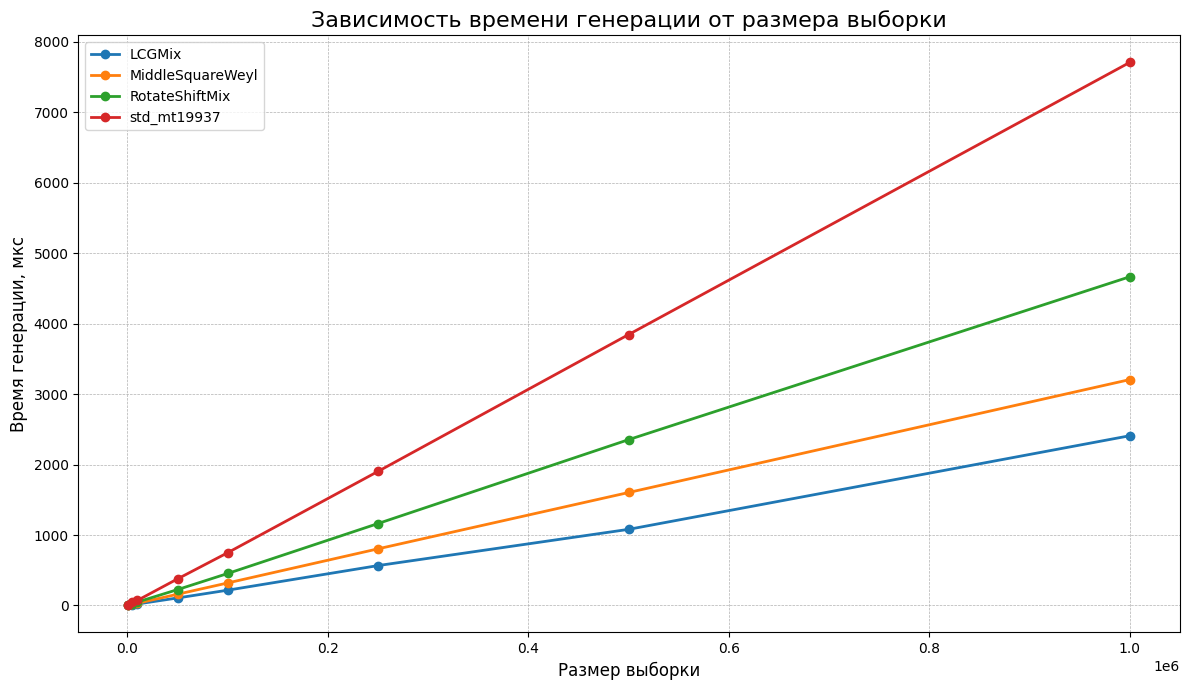

In [3]:
plt.figure(figsize=(12, 7))

for method in df["method"].unique():
    data = df[df["method"] == method]

    plt.plot(
        data["size"],
        data["microseconds"],
        marker="o",
        linewidth=2,
        label = method
    )

plt.title("Зависимость времени генерации от размера выборки", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Время генерации, мкс", fontsize=12)

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("generation_time.png", dpi=300)
plt.show()

In [4]:
df3 = pd.read_csv("results_summary.csv")
df3.head()

,method,sample,mean,stddev,coefficient_variation,chi_square,chi_critical,chi_pass
0,LCGMix,1,0.507572,0.287953,0.567315,18.0312,21.0129,1
1,LCGMix,2,0.491301,0.290387,0.591057,13.6008,21.0129,1
2,LCGMix,3,0.496905,0.286529,0.576628,4.3396,21.0129,1
3,LCGMix,4,0.502958,0.285984,0.568604,14.8436,21.0129,1
4,LCGMix,5,0.504205,0.289303,0.573780,12.8936,21.0129,1


In [5]:
passed3 = {}

for method in df3["method"].unique():
    data = df3[df3["method"] == method]["chi_pass"]
    passed3[method] = data.sum()
    print(f"{method} прошел {data.sum()}/20 тестов на равномерность")

LCGMix прошел 17/20 тестов на равномерность
MiddleSquareWeyl прошел 19/20 тестов на равномерность
RotateShiftMix прошел 18/20 тестов на равномерность


Лучший генератор по итогам тестов на равномерность (п.4) - **MiddleSquareWeyl**

In [6]:
df2 = pd.read_csv("tests_detail.csv")
df2

,method,sample,test_name,statistic,passed
0,LCGMix,1,Frequency,0.95500,1
1,LCGMix,1,Runs,0.45000,1
2,LCGMix,1,Serial2,2.92372,1
3,LCGMix,1,Poker4,22.43040,1
4,LCGMix,1,OverlappingPermutations,132.39100,1
...,...,...,...,...,...
295,RotateShiftMix,20,Frequency,1.27000,1
296,RotateShiftMix,20,Runs,1.11000,1
297,RotateShiftMix,20,Serial2,3.34034,1
298,RotateShiftMix,20,Poker4,18.08720,1


In [7]:
m = {}

for method in df2["method"].unique():
    data = df2[df2["method"] == method]["passed"]
    m[method] = data.sum()
    print(f"{method} прошел {data.sum()}% тестов")

LCGMix прошел 95% тестов
MiddleSquareWeyl прошел 92% тестов
RotateShiftMix прошел 95% тестов


Лучший генератор по итогам тестов на равномерность и NIST тестов (п.5) - **RotateShiftMix**

In [8]:
print("Усредненные математические значения:\n")

for method in df3["method"].unique():
    mean = df3[df3["method"] == method]["mean"].mean()
    stddev = df3[df3["method"] == method]["stddev"].mean()
    cv = df3[df3["method"] == method]["coefficient_variation"].mean()
    print(f"{method}:\nСреднее - {round(mean, 3)}\nСтандартное отклонение - {round(stddev, 3)}\nКоэффициент вариации - {round(cv, 3)}\n")

Усредненные математические значения:

LCGMix:
Среднее - 0.5
Стандартное отклонение - 0.288
Коэффициент вариации - 0.577

MiddleSquareWeyl:
Среднее - 0.499
Стандартное отклонение - 0.288
Коэффициент вариации - 0.577

RotateShiftMix:
Среднее - 0.499
Стандартное отклонение - 0.288
Коэффициент вариации - 0.578

